# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import abjad
from IPython.display import Image, display
from collections import Counter

# Description

This notebook is the companion code to the manuscript "The MPB Corpus: A Dataset of Melody, Rhythm, Harmony, and Melody-Harmony Relationships in Brazilian Popular Music". It contains codes to compute all the metrics and graphs proposed in the manuscript, as well as codes to reproduce the figures and tables within the text. All figures and tables are thoroughly discussed in the paper.

# Functions

## Compute the compensated intervallic economy index (CIEI)

In [2]:
economy_idx = {'u': 0,
               'P': 1, 'p': -1,
               'A': 3, 'a': -3,
               'S': 5, 's': -5}

def compute_economy_idx(word):
    economy = 0
    for letter in word:
        economy += economy_idx[letter]
    
    if len(word) == 0:
        economy = 0
    else:
        economy = 1 - abs(economy/len(word))/5
    
    return economy

## Compute the countermetricity index (CMI)

In [3]:
contermetricity_idx = {'a': 0,
                       'b': 1 - 0.9,
                       'c': 1 - 0.2,
                       'd': 1 - 0.3,
                       'e': 1 - 0.4,
                       'f': 1 - 0.3,
                       'g': 1 - 0.2,
                       'h': 1 - 0.35,
                       'i': 1 - 0.45,
                       'j': 1 - 0.55,
                       'k': 0.47,
                       'l': 0.62,
                       'm': 0.79,
                       'n': 1,
                       'o': 0.69,
                       'p': 0.58,
                       'q': 0.485,
                       'r': 0.655,
                       's': 0.605,
                       't': 0.555,
                       'u': 0.755,
                       'v': 0.355,
                       'w': 0.255,
                       'x': 0.255,
                       'y': 0.255,
                       'z': 0.255}

def compute_countermetricity_idx(word):
    idx = 0
    for letter in word:
        idx += contermetricity_idx[letter]
    
    eff_len_word = len(word) - word.count('a')

    if eff_len_word > 1 and word[-1] == 'b':
        idx *= 0.8
    
    return idx/eff_len_word

## Compute the melodic anchoring index (MAI)

In [4]:
nf_weights = {'x': 0,
              '1': 9, '3': 7, '5': 8,
              '6': 5, '7': 5,
              '9': 3, '11': 3, '13': 3, '14': 3,
              'b9/#9': 1, '#11': 1, 'b13': 1}

def compute_anchoring_index(df):

    note_function_count = Counter(df['note_function'])

    weighted_sum = 0
    for nf in note_function_count.keys():
        weighted_sum += note_function_count[nf]*nf_weights[nf]

    weighted_sum /= (sum(note_function_count.values()) - note_function_count['x'])

    Kmin = 1
    Kmax = 9

    anchoring_index = (weighted_sum - Kmin)/(Kmax - Kmin)

    return anchoring_index

## Plot the NF-web

In [5]:
min_scale_degree_to_angle = {'1': 0,
                             '#1/b2': np.pi/6,
                             '2': 2*np.pi/6,
                             '3': 3*np.pi/6,
                             '#3': 4*np.pi/6,
                             '4': 5*np.pi/6,
                             '#4/b5': 6*np.pi/6,
                             '5': 7*np.pi/6,
                             '6': 8*np.pi/6,
                             '#6': 9*np.pi/6,
                             'b7': 10*np.pi/6,
                             '7': 11*np.pi/6}

maj_scale_degree_to_angle = {'1': 0,
                             '#1/b2': np.pi/6,
                             '2': 2*np.pi/6,
                             '#2/b3': 3*np.pi/6,
                             '3': 4*np.pi/6,
                             '4': 5*np.pi/6,
                             '#4/b5': 6*np.pi/6,
                             '5': 7*np.pi/6,
                             '#5/b6': 8*np.pi/6,
                             '6': 9*np.pi/6,
                             '#6/b7': 10*np.pi/6,
                             '7': 11*np.pi/6}

note_function_to_radius = {'x': 1,
                           '1': 2, '3': 2, '5': 2,
                           '6': 3, '7': 3,
                           '9': 4, '11': 4, '13': 4, '14': 4,
                           'b9/#9': 5, '#11': 5, 'b13': 5}

def plot_nf_web(df):

    ## PREPARE DATA

    mode = df['mode'].unique()

    r_theta = []

    for _, notes in df.iterrows():
        if mode == 'minor':
            r_theta.append((note_function_to_radius[notes['note_function']], min_scale_degree_to_angle[notes['scale_degree']]))
        elif mode == 'major':
            r_theta.append((note_function_to_radius[notes['note_function']], maj_scale_degree_to_angle[notes['scale_degree']]))
        else:
            print('opa')

    r_theta_count = Counter(r_theta)

    r_theta_count_matrix = []

    for keys, vals in r_theta_count.items():
        r_theta_count_matrix.append([*keys, vals/sum(r_theta_count.values())])

    r_theta_count_matrix = np.array(r_theta_count_matrix)    

    ## PREPARE PLOT

    plt.figure(figsize = (25, 25))
    r = np.arange(1, 6)
    theta = np.pi * np.arange(0, 12)/6

    pts_fundo = []
    cor_fundo = []
    for rad in r:
        for ang in theta:
            pts_fundo.append([rad, ang])
            if int(6*ang/np.pi) == 0:
                cor_fundo.append('red')
            if mode == 'major':
                if int(6*ang/np.pi) in {2, 4, 5, 7, 9, 11}:
                    cor_fundo.append('blue')
                elif int(6*ang/np.pi) in {1, 3, 6, 8, 10}:
                    cor_fundo.append('gray')
            elif mode == 'minor':
                if int(6*ang/np.pi) in {2, 3, 5, 7, 8, 11}:
                    cor_fundo.append('blue')
                elif int(6*ang/np.pi) in {1, 4, 6, 9, 10}:
                    cor_fundo.append('gray')

    theta_ang = theta/np.pi * 180

    # PLOT BACKGROUND

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize = (8, 8))
    ax.scatter(np.array(pts_fundo)[:,1], np.array(pts_fundo)[:,0], marker = '.', s = 20, c = cor_fundo, alpha = 0.1)
    
    # CREATE COLORMAP
    
    plasma_5_plus = mpl.colormaps['plasma'].resampled(5 + 1)

    def _forward(x):
        return np.clip(x, a_min = 0, a_max = 10)
    
    def _inverse(x):
        return x
    
    norm = mpl.colors.FuncNorm((_forward, _inverse), vmin = 0, vmax = 10)

    # PLOT NF-WEB

    r_theta_count_matrix = []

    for keys, vals in r_theta_count.items():
        r_theta_count_matrix.append([*keys, vals/sum(r_theta_count.values())])

    r_theta_count_matrix = np.array(r_theta_count_matrix)
    
    teia = ax.scatter(r_theta_count_matrix[:,1], r_theta_count_matrix[:,0], marker = 'o', c = 100*r_theta_count_matrix[:,2], cmap = plasma_5_plus, norm = norm, s = 80)

    # FINAL ADJUSTMENTS

    # plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.size'] = 14

    ax.set_thetagrids(theta_ang)
    ax.set_thetalim(0, 2*np.pi)
    if mode == 'major':
        ax.set_xticklabels([1, ' ', 2, ' ', 3, 4, ' ', 5, ' ', 6, ' ', 7])
    elif mode == 'minor':
        ax.set_xticklabels([1, ' ', 2, 3, ' ', 4, ' ', 5, 6, ' ', ' ', 7])

    ax.set_rmax(5.15)
    ax.set_rticks(range(1, 6))
    ax.set_yticklabels([' ', ' ', ' ', ' ', ' '])

    ax.grid(True)
    ax.spines['polar'].set_visible(False)
    ax.set_axisbelow(True)
    

    cbar = fig.colorbar(teia, label = 'Percentage of occurence', orientation = 'vertical', fraction = 0.05)

    cbar.set_ticks([0.75 + t*1.7 for t in range(5 + 1)])
    cbar.set_ticklabels(['0% ~ 2%', '2% ~ 4%', '4% ~ 6%', '6% ~ 8%', '8% ~ 10%', '> 10%'] )

    ax.set_title(f'MAI: {compute_anchoring_index(df):.3f}', va = 'bottom', pad = 30) # , fontdict={'fontname': 'Times New Roman'})

    plt.tight_layout()

    # plt.savefig('teia.pdf', dpi = 1200)

    plt.show()

## Convert c-letters to Parsons Code

In [6]:
def contour_to_parsons(df, original_col = "c_word", new_col = "c_word_parsons"):
    mapping = {
        "u": "R",
        "A": "U", "P": "U", "S": "U",
        "a": "D", "p": "D", "s": "D"
    }
    
    df[new_col] = df[original_col].apply(lambda x: "".join(mapping.get(c, c) for c in x))
    return df

## Convert c-letters do Dowling notation for contour

In [7]:
def contour_to_dowling(df, original_col = "c_word", new_col = "c_word_dowling"):
    mapping = {
        "u": "u",
        "A": "S", "P": "T", "S": "L",
        "a": "s", "p": "t", "s": "l"
    }
    
    df[new_col] = df[original_col].apply(lambda x: "".join(mapping.get(c, c) for c in x))
    return df

## Visualize r-words

In [8]:
def r_letter_to_lily(letter):
    if letter == 'a':
        lily_code = r"r4 _\markup{a}"
    elif letter == 'b':
        lily_code = r"c'4 _\markup{b}"
    elif letter == 'c':
        lily_code = r"r16 _\markup{c} c'8."
    elif letter == 'd':
        lily_code = r"\tuplet 3/2 { r8 _\markup{d} c'4 }"
    elif letter == 'e':
        lily_code = r"r8 _\markup{e} c'8"
    elif letter == 'f':
        lily_code = r"\tuplet 3/2 { r4 _\markup{f} c'8 }"
    elif letter == 'g':
        lily_code = r"r8. _\markup{g} c'16"
    elif letter == 'h':
        lily_code = r"c'16 _\markup{h} c'16 r8"
    elif letter == 'i':
        lily_code = r"\tuplet 3/2 { c'8 _\markup{i} c'8 r8 }"
    elif letter == 'j':
        lily_code = r"c'8 _\markup{j} c'8"
    elif letter == 'k':
        lily_code = r"\tuplet 3/2 { c'4 _\markup{k} c'8 }"
    elif letter == 'l':
        lily_code = r"c'8. _\markup{l} c'16"
    elif letter == 'm':
        lily_code = r"r16 _\markup{m} c'16 c'16 r16"
    elif letter == 'n':
        lily_code = r"r16 _\markup{n} c'8 c'16"
    elif letter == 'o':
        lily_code = r"\tuplet 3/2 { r8 _\markup{o} c'8 c'8 }"
    elif letter == 'p':
        lily_code = r"r8 _\markup{p} c'16 c'16"
    elif letter == 'q':
        lily_code = r"c'16 _\markup{q} c'16 c'16 r16"
    elif letter == 'r':
        lily_code = r"c'16 _\markup{r} c'8 c'16"
    elif letter == 's':
        lily_code = r"\tuplet 3/2 { c'8 _\markup{s} c'8 c'8 }"
    elif letter == 't':
        lily_code = r"c'8 _\markup{t} c'16 c'16"
    elif letter == 'u':
        lily_code = r"r16 _\markup{u} c'16 c'16 c'16"
    elif letter == 'v':
        lily_code = r"c'16 _\markup{v} c'16 c'16 c'16"
    elif letter == 'w':
        return
    elif letter == 'x':
        return
    elif letter == 'y':
        return
    elif letter == 'z':
        return
    return lily_code

def concat_lily(list):
    rhythms = ""
    for symbol in list:
        rhythms += " " + symbol
    
    return rhythms

def visualize_r_word(r_word):
    rhythms_lily_concat = []
    for rhythm in r_word:
        rhythms_lily_concat.append([concat_lily([r_letter_to_lily(letter) for letter in rhythm])])
    
    lily_string = " ".join(segment[0] for segment in rhythms_lily_concat)

    staff = abjad.Staff(lily_string)

    abjad.override(staff).StaffSymbol.line_count = 1

    abjad.attach(abjad.Clef("percussion"), staff[0])

    abjad.override(staff).TimeSignature.stencil = False

    abjad.override(staff).BarLine.stencil = False
    abjad.override(staff).SpanBar.stencil = False

    score = abjad.Score([staff])

    # abjad.show(score)

    png_path = "score.png"
    abjad.persist.as_png(score, png_path)
    
    display(Image(filename=png_path))

## Convert r-words to 12-dimensional vector with attack points

In [9]:
atk_pts = {
    'a': np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'b': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'c': np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
    'd': np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
    'e': np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
    'f': np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),
    'g': np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
    'h': np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
    'i': np.array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
    'j': np.array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
    'k': np.array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),
    'l': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
    'm': np.array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
    'n': np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]),
    'o': np.array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]),
    'p': np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
    'q': np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
    'r': np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]),
    's': np.array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]),
    't': np.array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
    'u': np.array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]),
    'v': np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]),
    'w': np.array([1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]),
    'x': np.array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0]),
    'y': np.array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]),
    'z': np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])
}

def r_word_to_attack_points(r_word):
    attack_points = []
    for letter in r_word:
        attack_points.append(atk_pts[letter])
    
    return attack_points

## Convert from genealogic chord notation to pitch classes

In [21]:
def chord_type_to_pitch_class(df, original_col = "chord_type", new_col = "ct_pitch_class"):
    gen_to_pc = {'Z0': [0, 4, 7, 11],
                'Z1': [0, 4, 7, 9],
                'Z1.1': [0, 2, 4, 7, 9],
                'Z1.1.1': [0, 2, 4, 6, 7, 9],
                'Z1.2': [0, 4, 6, 7, 9, 11],
                'Z2': [0, 2, 4, 7, 11],
                'Z2.1': [0, 2, 4, 6, 7, 11],
                'Z2.2': [0, 2, 4, 8, 11],
                'Z3': [0, 4, 8, 11],
                'Z3.1': [0, 4, 6, 8, 11],
                'Z3.1.1': [0, 2, 4, 6, 8, 11],
                'Z4': [0, 4, 8, 11],
                'Z5': [0, 4, 7, 9, 11],
                'Z5.1': [0, 2, 4, 7, 9, 11],
                'Z5.1.1': [0, 2, 4, 6, 8, 9, 11],
                'Z5.2': [0, 4, 6, 8, 9, 11],
                'Y0': [0, 4, 7, 10],
                'Y1': [0, 5, 7, 10],
                'Y1.1': [0, 2, 5, 7, 10],
                'Y1.1.1': [0, 2, 5, 6, 7, 10],
                'Y1.1.1.1': [0, 2, 5, 6, 7, 9, 10],
                'Y1.1.1.1.1': [0, 2, 5, 6, 7, 8, 10],
                'Y1.1.1.1.2': [0, 1, 5, 6, 7, 8, 10],
                'Y1.1.1.1.2.1': [0, 1, 3, 5, 6, 7, 8, 10],
                'Y1.1.1.1.3': [0, 3, 5, 6, 7, 8, 10],
                'Y1.1.1.2': [0, 1, 5, 6, 7, 10],
                'Y1.1.1.2.1': [0, 1, 5, 6, 7, 9, 10],
                'Y1.1.1.2.2': [0, 1, 3, 5, 6, 7, 9, 10],
                'Y1.1.1.3': [0, 3, 5, 6, 7, 10],
                'Y1.1.1.3.1': [0, 3, 5, 6, 7, 9, 10],
                'Y1.1.2': [0, 2, 5, 7, 9, 10],
                'Y1.1.2.1': [0, 2, 5, 7, 8, 10],
                'Y1.1.2.1.1': [0, 1, 5, 7, 8, 10],
                'Y1.1.2.1.2': [0, 3, 5, 7, 8, 10],
                'Y1.1.2.2': [0, 1, 5, 7, 9, 10],
                'Y1.1.2.2.1': [0, 1, 3, 5, 7, 9, 10],
                'Y1.1.2.2.1.1': [0, 1, 3, 5, 7, 8, 10],
                'Y1.1.2.3': [0, 3, 5, 7, 9, 10],
                'Y1.1.3': [0, 1, 5, 7, 10],
                'Y1.1.3.1': [0, 1, 3, 5, 7, 10],
                'Y1.1.3.1.1': [0, 1, 3, 5, 6, 7, 10],
                'Y1.1.4': [0, 3, 5, 7, 10],
                'Y1.2': [0, 5, 6, 7, 10],
                'Y1.2.1': [0, 5, 6, 7, 9, 10],
                'Y1.2.1.1': [0, 5, 6, 7, 8, 10],
                'Y1.3': [0, 5, 7, 9, 10],
                'Y1.3.1': [0, 5, 7, 8, 10],
                'Y2': [0, 2, 4, 7, 10],
                'Y2.1': [0, 2, 4, 6, 7, 10],
                'Y2.1.1': [0, 2, 4, 6, 7, 9, 10],
                'Y2.1.1.1': [0, 1, 4, 6, 7, 9, 10],
                'Y2.1.1.1.1': [0, 1, 3, 4, 6, 7, 9, 10],
                'Y2.1.1.1.2': [0, 1, 4, 6, 7, 8, 10],
                'Y2.1.1.2': [0, 3, 4, 6, 7, 9, 10],
                'Y2.1.1.3': [0, 2, 4, 6, 7, 8, 10],
                'Y2.1.2': [0, 1, 4, 6, 7, 10],
                'Y2.1.2.1': [0, 1, 3, 4, 6, 7, 10],
                'Y2.1.3': [0, 3, 4, 6, 7, 10],
                'Y2.1.3.1': [0, 3, 4, 6, 7, 8, 10],
                'Y2.2': [0, 2, 4, 7, 9, 10],
                'Y2.2.1': [0, 1, 4, 7, 9, 10],
                'Y2.2.1.1': [0, 1, 4, 7, 8, 10],
                'Y2.2.1.2': [0, 1, 3, 4, 7, 9, 10],
                'Y2.2.1.2.1': [0, 1, 3, 4, 7, 8, 10],
                'Y2.2.2': [0, 3, 4, 7, 9, 10],
                'Y2.2.2.1': [0, 3, 4, 7, 8, 10],
                'Y2.2.3': [0, 2, 4, 7, 8, 10],
                'Y2.3': [0, 1, 4, 7, 10],
                'Y2.3.1': [0, 1, 3, 4, 7, 10],
                'Y2.4': [0, 3, 4, 7, 10],
                'Y3': [0, 4, 6, 7, 10],
                'Y3.1': [0, 4, 6, 7, 9, 10],
                'Y3.1.1': [0, 4, 6, 7, 8, 10],
                'Y4': [0, 4, 7, 9, 10],
                'Y4.1': [0, 4, 7, 8, 10],
                'X0': [0, 4, 6, 10],
                'X1': [0, 5, 6, 10],
                'X1.1': [0, 2, 5, 6, 10],
                'X1.1.1': [0, 1, 5, 6, 10],
                'X1.1.1.1': [0, 1, 5, 6, 8, 10],
                'X1.1.1.2': [0, 1, 3, 5, 6, 10],
                'X1.1.2': [0, 3, 5, 6, 10],
                'X1.1.2.1': [0, 3, 5, 6, 8, 10],
                'X1.1.3': [0, 2, 5, 6, 8, 10],
                'X1.2': [0, 5, 6, 8, 10],
                'X2': [0, 2, 4, 6, 10],
                'X2.1': [0, 1, 4, 6, 10],
                'X2.1.1': [0, 1, 4, 6, 8, 10],
                'X2.1.1.1': [0, 1, 3, 4, 6, 8, 10],
                'X2.1.2': [0, 1, 3, 4, 6, 10],
                'X2.2': [0, 3, 4, 6, 10],
                'X2.2.1': [0, 3, 4, 6, 8, 10],
                'X3': [0, 4, 6, 8, 10],
                'X3.1': [0, 2, 4, 6, 8, 10],
                'W0': [0, 4, 8, 10],
                'W1': [0, 5, 8, 10],
                'W1.1': [0, 2, 5, 8, 10],
                'W1.1.1': [0, 1, 5, 8, 10],
                'W1.1.1.1': [0, 1, 3, 5, 8, 10],
                'W1.1.2': [0, 3, 5, 8, 10],
                'W2': [0, 2, 4, 8, 10],
                'W2.1': [0, 1, 4, 8, 10],
                'W2.1.1': [0, 1, 3, 4, 8, 10],
                'W2.2': [0, 3, 4, 8, 10],
                'V0': [0, 4, 7],
                'V1': [0, 5, 7],
                'V1.1': [0, 2, 5, 7],
                'V1.1.1': [0, 2, 5, 8],
                'V1.2': [0, 5, 8],
                'V2': [0, 2, 4, 7],
                'V2.1': [0, 2, 4, 6, 7],
                'V2.1.1': [0, 2, 4, 6, 8],
                'V2.2': [0, 2, 4, 8],
                'V3': [0, 4, 6, 7],
                'V3.1': [0, 4, 6, 8],
                'V4': [0, 2, 4, 8],
                'z0': [0, 3, 7, 10],
                'z1': [0, 3, 7, 9],
                'z1.1': [0, 2, 3, 7, 9],
                'z1.1.1': [0, 2, 3, 5, 7, 9],
                'z1.1.2': [0, 2, 3, 7, 8],
                'z1.2': [0, 3, 5, 7, 9],
                'z1.2.1': [0, 3, 5, 7, 8],
                'z1.3': [0, 3, 7, 8],
                'z2': [0, 2, 3, 7, 10],
                'z2.1': [0, 2, 3, 5, 7, 10],
                'z3': [0, 3, 5, 7, 10],
                'y0': [0, 3, 6, 10],
                'y1': [0, 2, 3, 6, 10],
                'y1.1': [0, 2, 3, 5, 6, 10],
                'y1.1.1': [0, 2, 3, 5, 6, 8, 10],
                'y1.2': [0, 2, 3, 6, 8, 10],
                'y2': [0, 3, 5, 6, 10],
                'y2.1': [0, 3, 5, 6, 8, 10],
                'y3': [0, 3, 6, 8, 10],
                'x0': [0, 3, 6, 9],
                'x1': [0, 2, 3, 6, 9],
                'x1.1': [0, 2, 3, 5, 6, 9],
                'x1.1.1': [0, 2, 3, 5, 6, 8, 9],
                'x1.1.1.1': [0, 2, 3, 5, 6, 8, 9, 11],
                'x1.2': [0, 2, 3, 6, 8, 9],
                'x1.2.1': [0, 2, 3, 6, 8, 9, 11],
                'x1.3': [0, 2, 3, 6, 9, 11],
                'x2': [0, 3, 5, 6, 9],
                'x2.1': [0, 3, 5, 6, 8, 9],
                'x2.1.1': [0, 3, 5, 6, 8, 9, 11],
                'x2.2': [0, 3, 5, 6, 9, 11],
                'x3': [0, 3, 6, 8, 9],
                'x3.1': [0, 3, 6, 8, 9, 11],
                'x4': [0, 3, 6, 9, 11],
                'w0': [0, 3, 7, 11],
                'w1': [0, 2, 3, 7, 11],
                'w1.1': [0, 2, 3, 5, 7, 11],
                'w2': [0, 3, 5, 7, 11],
                'v0': [0, 3, 7],
                'v1': [0, 2, 3, 7],
                'v1.1': [0, 2, 3, 5, 7],
                'v1.2': [0, 2, 3, 6],
                'v2': [0, 3, 5, 7],
                'v2.1': [0, 3, 5, 6],
                'v3': [0, 3, 6]}
    
    df[new_col] = df[original_col].map(gen_to_pc)
    return df

# Exploratory data analysis

## Load datasets

It is important to load the file `contour_rhythm.csv` with the option `keep_default_na = False`, since there are a few occurences
of the r-word "nan" in the following pieces:
* Chico Buarque - Acorda Amor
* Gilberto Gil - Rebento
* Tom Jobim - Bebel
* Ivan Lins - Leva e Traz

There are also a few occurences of the empty c-word, representing a segment with a single syllabe, in the following pieces:
* Chico Buarque - Calice
* Gilberto Gil - Drao
* Tom Jobim - Modinha
* Milton Nascimento - Os Povos

These instances should not count as missing values.

In [11]:
contour_rhythm = pd.read_csv('contour_rhythm.csv', keep_default_na = False)
contour_rhythm.head()

,corpus_id,composition_id,composition_name,word_index,c_word,r_word
0,BOSCO,1,Agnus sei,1,uuPu,jjb
1,BOSCO,1,Agnus sei,2,pppA,fsb
2,BOSCO,1,Agnus sei,3,uuPu,jjb
3,BOSCO,1,Agnus sei,4,upPPAupu,jjbjeb
4,BOSCO,1,Agnus sei,5,PupuP,jjj


In [22]:
harmony = pd.read_csv('harmony.csv')
harmony.head()

,corpus_id,composition_id,composition_name,chord_index,root,bass,chord_type,chord_symbol,functional_category,key,mode,position
0,BOSCO,1,Agnus sei,1,4,4,z2,*m7.9,I,4,minor,1.0
1,BOSCO,1,Agnus sei,2,2,9,z2,*m7.9,bVIIm7,4,minor,8.0
2,BOSCO,1,Agnus sei,3,1,1,y0,*Ø,VI,4,minor,10.0
3,BOSCO,1,Agnus sei,4,0,0,Z0,*M7,VI,4,minor,11.0
4,BOSCO,1,Agnus sei,5,2,6,z1,*m6,II__X,4,minor,12.0


In [13]:
note_function = pd.read_csv('note_function.csv')
note_function.head()

,corpus_id,composition_id,composition_name,mode,note_index,scale_degree,note_function
0,BOSCO,1,Agnus sei,minor,1,3,3
1,BOSCO,1,Agnus sei,minor,2,4,11
2,BOSCO,1,Agnus sei,minor,3,3,3
3,BOSCO,1,Agnus sei,minor,4,2,x
4,BOSCO,1,Agnus sei,minor,5,1,1


## Melodic rhythm

### Bar chart showing the proportion of each r-letter in each analyzed corpora

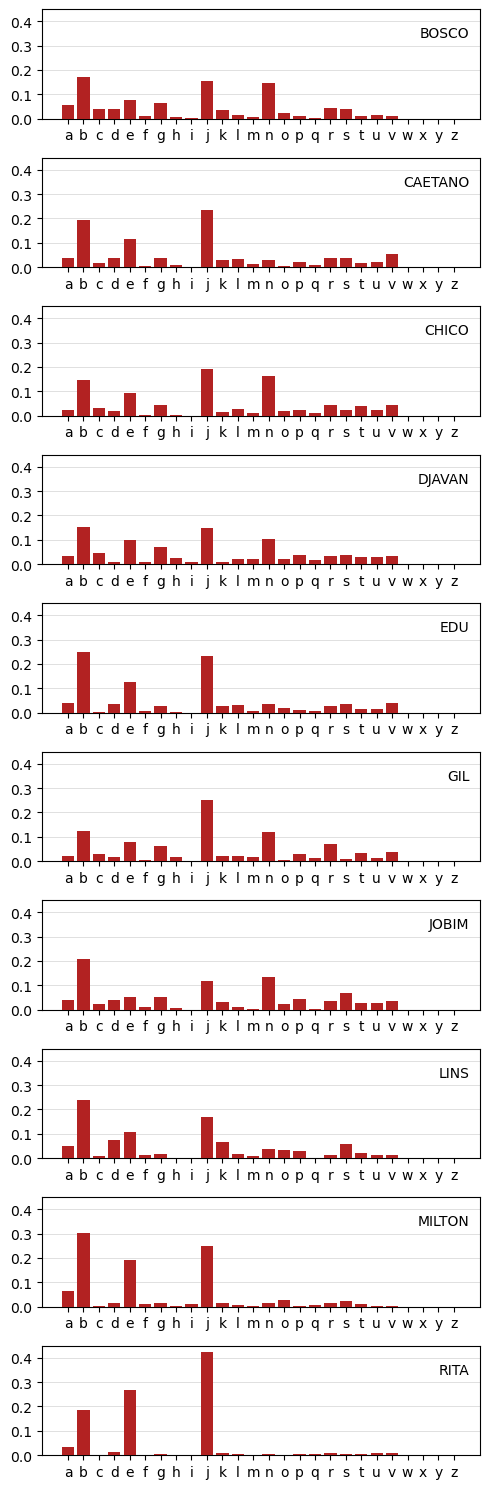

In [13]:
r_letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

r_count = {}

for corpus in contour_rhythm['corpus_id'].unique():
    contador_aux = Counter(''.join(list(contour_rhythm[contour_rhythm['corpus_id'] == corpus]['r_word'])))
    r_count[corpus] = {letter: contador_aux.get(letter, 0) for letter in 'abcdefghijklmnopqrstuvwxyz'}

plt.figure(figsize = (5, 15))

sub = 1
for corpus in r_count.keys():
    plt.subplot(10, 1, sub)
    r_letters_prop = np.array(list(r_count[corpus].values()))/np.array(list(r_count[corpus].values())).sum()
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = r_letters, height = r_letters_prop, color = 'firebrick', zorder = 3)
    plt.ylim(0, 0.45)
    plt.yticks([0, 0.1, 0.2, 0.3, 0.4])
    plt.text(x = 26, y = 0.38, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('r-letters-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

### Distribution of countermetric r-letters by corpus, in percentage.

In [14]:
r_pct = {}

for corpus in r_count.keys():
    total = sum(r_count[corpus].values())
    r_pct[corpus] = {letter: count/total for letter, count in r_count[corpus].items()}

countermetric_letters = ['c', 'e', 'g', 'm', 'n', 'p', 'u']

r_pct_countermetric = {}

for corpus in r_count.keys():
    r_pct_countermetric[corpus] = {letter: r_pct[corpus][letter] for letter in countermetric_letters}

100*pd.DataFrame(r_pct_countermetric).round(3).T

,c,e,g,m,n,p,u
BOSCO,3.9,7.6,6.5,0.6,14.8,1.2,1.6
CAETANO,1.6,11.7,3.8,1.3,2.8,2.1,2.1
CHICO,3.2,9.5,4.5,1.1,16.3,2.2,2.3
DJAVAN,4.5,9.9,7.2,2.1,10.3,3.8,3.1
EDU,0.2,12.6,2.8,0.6,3.4,1.1,1.5
GIL,2.8,7.8,6.1,1.9,11.8,3.2,1.5
JOBIM,2.2,5.3,5.2,0.4,13.4,4.5,2.8
LINS,1.0,10.8,1.8,1.1,3.9,2.8,1.3
MILTON,0.2,19.0,1.4,0.5,1.4,0.5,0.1
RITA,0.3,26.9,0.5,0.1,0.5,0.5,0.8


### Total occurrence of countermetric r-letters for each composer, in percentage

In [15]:
100*pd.DataFrame(r_pct_countermetric).sum().round(3).T

BOSCO      36.2
CAETANO    25.4
CHICO      39.2
DJAVAN     40.9
EDU        22.3
GIL        35.0
JOBIM      33.9
LINS       22.8
MILTON     23.1
RITA       29.6
dtype: float64

### Metric profile by analyzed corpus, in percentage

In [16]:
atk_pts = {
    'a': np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'b': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    'c': np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
    'd': np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
    'e': np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
    'f': np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),
    'g': np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
    'h': np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
    'i': np.array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
    'j': np.array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
    'k': np.array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),
    'l': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
    'm': np.array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
    'n': np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]),
    'o': np.array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]),
    'p': np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
    'q': np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
    'r': np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]),
    's': np.array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]),
    't': np.array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
    'u': np.array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]),
    'v': np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]),
    'w': np.array([1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]),
    'x': np.array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0]),
    'y': np.array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]),
    'z': np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])
}

atk_pts_count = {}

for corpus in contour_rhythm['corpus_id'].unique():
    
    atk_pts_count[corpus] = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

    for letter in ''.join(contour_rhythm[contour_rhythm['corpus_id'] == corpus]['r_word']):
        atk_pts_count[corpus] += atk_pts[letter]

atk_pts_pct = {}

for corpus in atk_pts_count.keys():
    total = atk_pts_count[corpus].sum()
    atk_pts_pct[corpus] = atk_pts_count[corpus]/total

100*pd.DataFrame(atk_pts_pct).round(3).T.rename(columns = {x: x + 1 for x in range(12)})

,1,2,3,4,5,6,7,8,9,10,11,12
BOSCO,31.0,0.0,0.0,17.0,6.7,0.0,18.1,0.0,7.1,20.2,0.0,0.0
CAETANO,37.6,0.0,0.0,10.9,4.7,0.0,27.9,0.0,4.5,14.4,0.0,0.0
CHICO,29.6,0.0,0.0,18.0,3.2,0.0,23.8,0.0,3.3,22.1,0.0,0.0
DJAVAN,29.3,0.0,0.0,17.6,4.5,0.0,23.7,0.0,4.4,20.5,0.0,0.0
EDU,40.7,0.0,0.0,8.3,5.5,0.0,27.6,0.0,5.5,12.4,0.0,0.0
GIL,32.3,0.0,0.0,17.1,1.5,0.0,25.8,0.0,2.2,21.0,0.0,0.0
JOBIM,31.0,0.0,0.0,15.3,7.4,0.0,17.8,0.0,7.5,20.9,0.0,0.0
LINS,38.2,0.0,0.0,6.7,10.7,0.0,23.2,0.0,10.9,10.4,0.0,0.0
MILTON,46.5,0.0,0.0,3.5,5.9,0.0,33.4,0.0,5.8,4.9,0.0,0.0
RITA,43.5,0.0,0.0,2.6,1.1,0.0,48.2,0.0,1.1,3.4,0.0,0.0


### Average countermetricity index

In [17]:
contour_rhythm['countermetricity_idx'] = contour_rhythm['r_word'].apply(compute_countermetricity_idx)

avg_countermetricity_idx = {}

for corpus in contour_rhythm['corpus_id'].unique():
    avg_countermetricity_idx[corpus] = contour_rhythm[contour_rhythm['corpus_id'] == corpus]['countermetricity_idx'].mean()

pd.DataFrame.from_dict(avg_countermetricity_idx, orient = 'index', columns = ['CMI']).round(3)

,CMI
BOSCO,0.559
CAETANO,0.463
CHICO,0.564
DJAVAN,0.558
EDU,0.436
GIL,0.552
JOBIM,0.531
LINS,0.446
MILTON,0.388
RITA,0.429


## Melodic contour

### Bar chart showing the proportion of each c-letter in each analyzed corpora

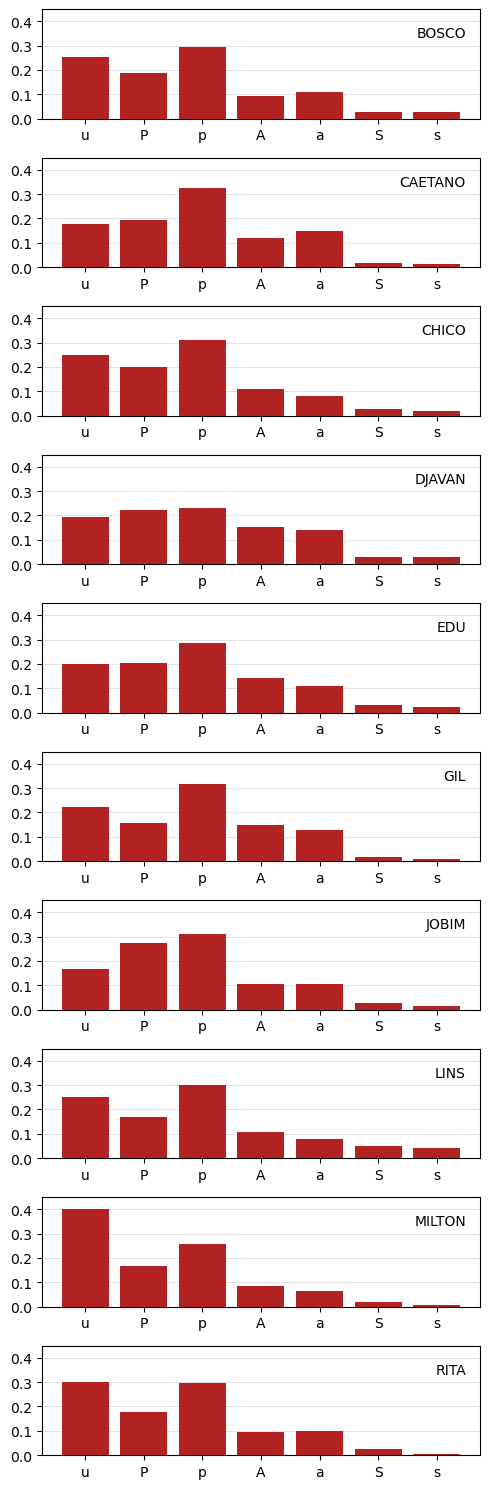

In [18]:
c_letters = ['u', 'P', 'p', 'A', 'a', 'S', 's']

c_count = {}

for corpus in contour_rhythm['corpus_id'].unique():
    contador_aux = Counter(''.join(list(contour_rhythm[contour_rhythm['corpus_id'] == corpus]['c_word'])))
    c_count[corpus] = {letter: contador_aux.get(letter, 0) for letter in 'uPpAaSs'}

plt.figure(figsize = (5, 15))
sub = 1
for corpus in r_count.keys():
    plt.subplot(10, 1, sub)
    c_letters_prop = np.array(list(c_count[corpus].values()))/np.array(list(c_count[corpus].values())).sum()
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = c_letters, height = c_letters_prop, color = 'firebrick', zorder = 3)
    plt.ylim(0, 0.45)
    plt.yticks([0, 0.1, 0.2, 0.3, 0.4])
    plt.text(x = 6.5, y = 0.38, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('c-letters-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

### Absolute frequency of the word lenghts in each analyzed corpora. Maximum value of each column is shown in bold

In [19]:
contour_rhythm['economy_idx'] = contour_rhythm['c_word'].apply(compute_economy_idx)

count_atk_pts = {}
avg_economy_idx = {}

for corpus in contour_rhythm['corpus_id'].unique():
    count_atk_pts[corpus] = Counter(contour_rhythm[contour_rhythm['corpus_id'] == corpus]['c_word'].str.len() + 1)
    avg_economy_idx[corpus] = contour_rhythm[contour_rhythm['corpus_id'] == corpus]['economy_idx'].mean()

pd.DataFrame(count_atk_pts).sort_index().style.highlight_max(axis=0, props='font-weight: bold;').format("{:.0f}")

,BOSCO,CAETANO,CHICO,DJAVAN,EDU,GIL,JOBIM,LINS,MILTON,RITA
1,nan,nan,1,nan,nan,1,2,nan,1,nan
2,29,12,12,28,17,6,22,19,15,24
3,83,37,61,96,39,80,72,46,57,75
4,109,69,104,105,94,114,151,98,114,116
5,137,99,111,125,106,118,154,94,122,134
6,151,94,137,129,98,133,192,114,160,123
7,159,110,114,128,82,103,119,153,102,95
8,162,104,124,87,149,134,121,135,115,83
9,66,41,51,43,47,51,54,54,58,42
10,28,42,44,50,56,49,46,40,26,32


### Average countermetricity index

In [20]:
pd.DataFrame.from_dict({key: round(value, 3) for key, value in avg_economy_idx.items()}, orient = 'index', columns = ['CIEI'])

,CIEI
BOSCO,0.856
CAETANO,0.873
CHICO,0.887
DJAVAN,0.863
EDU,0.867
GIL,0.880
JOBIM,0.888
LINS,0.867
MILTON,0.898
RITA,0.886


## Harmony

### Bar chart showing the proportion of the most common chord functions in each analyzed corpora

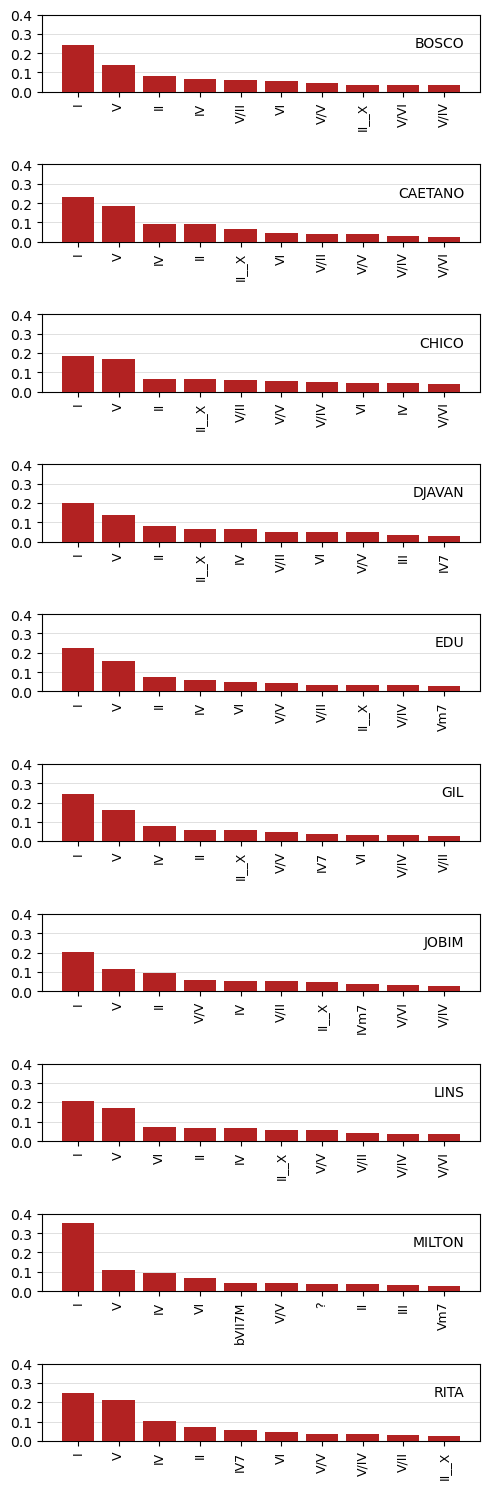

In [22]:
plt.figure(figsize = (5, 15))

sub = 1
for corpus in harmony['corpus_id'].unique():
    count_functions = Counter(harmony[harmony['corpus_id'] == corpus]['functional_category'])
    total_functions = sum(count_functions.values())
    most_common = [(item, count / total_functions) for item, count in count_functions.most_common(10)]
    functions, proportions = zip(*most_common)

    plt.subplot(10, 1, sub)
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = functions, height = proportions, color = 'firebrick', zorder = 3)
    plt.xticks(rotation = 90, fontsize = 9)
    plt.ylim(0, 0.4)
    plt.yticks([0, 0.1, 0.2, 0.3, 0.4])
    plt.text(x = 9.5, y = 0.29, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('most-common-functions-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

### Bar chart showing the proportion of each chord *genera* in each analyzed corpora

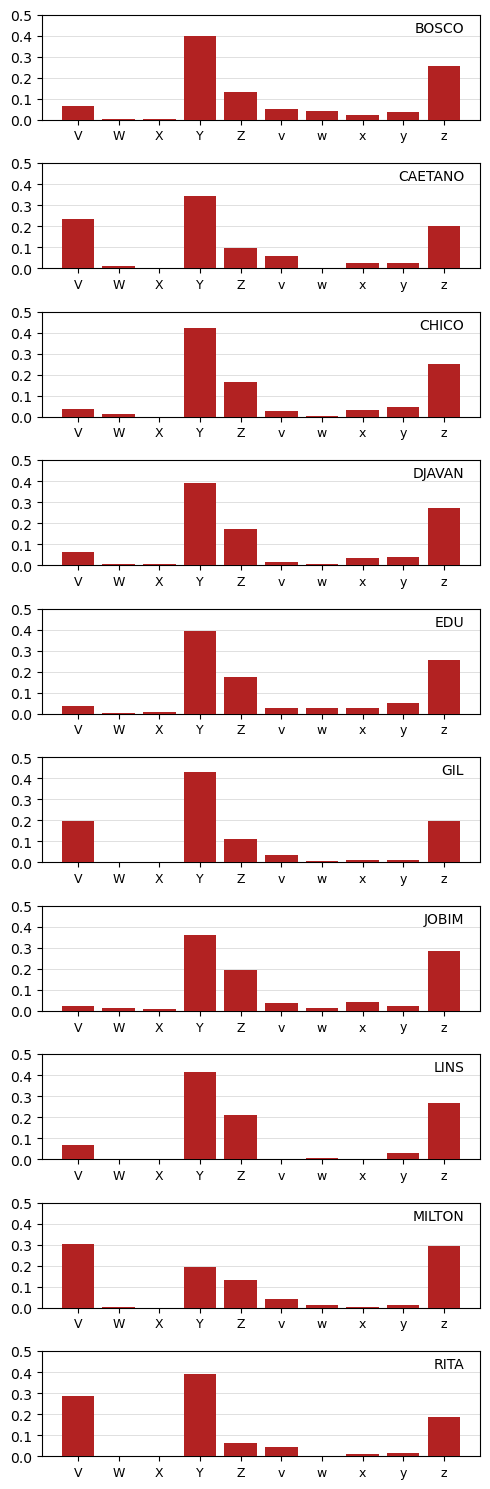

In [23]:
chord_types = ['V', 'W', 'X', 'Y', 'Z', 'v', 'w', 'x', 'y', 'z']

plt.figure(figsize = (5, 15))

sub = 1
for corpus in harmony['corpus_id'].unique():
    count_chord_types = Counter(harmony[harmony['corpus_id'] == corpus]['chord_type'].str[0])
    count_chord_types_ordered = {chord_type: count_chord_types[chord_type] for chord_type in chord_types}
    total_chord_types = sum(count_chord_types.values())
    prop_chord_types_ordered = np.array(list(count_chord_types_ordered.values()))/total_chord_types

    plt.subplot(10, 1, sub)
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = chord_types, height = prop_chord_types_ordered, color = 'firebrick', zorder = 3)
    plt.xticks(fontsize = 9)
    plt.ylim(0, 0.50)
    plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    plt.text(x = 9.5, y = 0.47, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('chord-type-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

### Bar chart showing the proportion of the most common chord qualities in each analyzed corpora (figure not displayed in the manuscript)

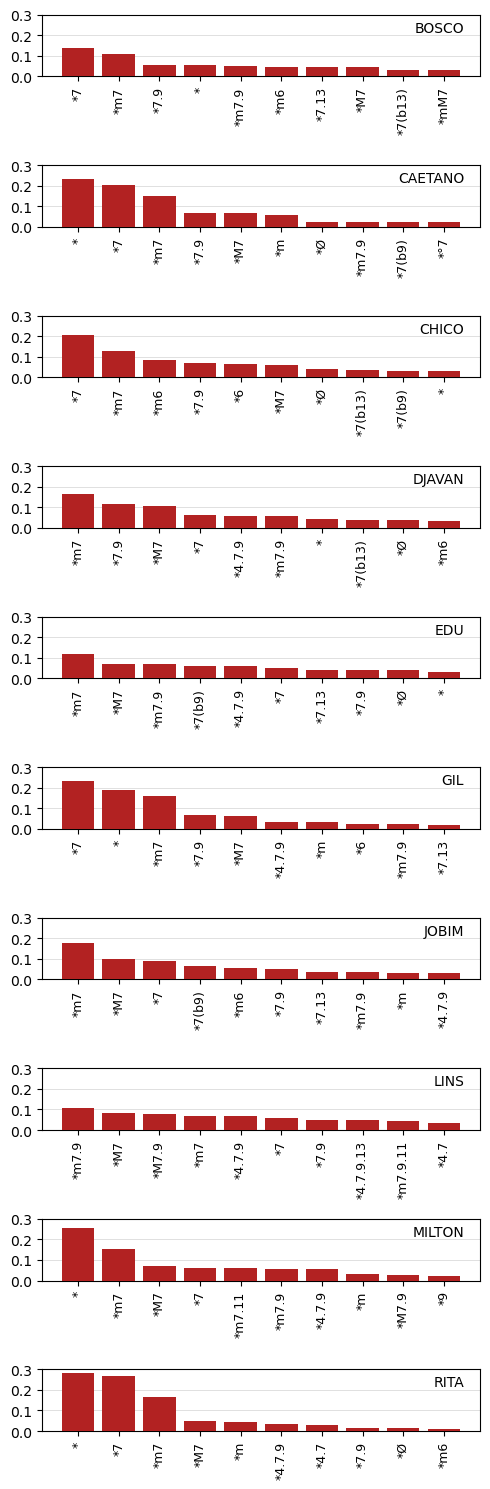

In [24]:
plt.figure(figsize = (5, 15))

sub = 1
for corpus in harmony['corpus_id'].unique():
    count_chord_symbols = Counter(harmony[harmony['corpus_id'] == corpus]['chord_symbol'])
    total_chord_symbols = sum(count_chord_symbols.values())
    most_common = [(item, count / total_chord_symbols) for item, count in count_chord_symbols.most_common(10)]
    functions, proportions = zip(*most_common)

    plt.subplot(10, 1, sub)
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = functions, height = proportions, color = 'firebrick', zorder = 3)
    plt.xticks(rotation = 90, fontsize = 9)
    plt.ylim(0, 0.30)
    plt.yticks([0, 0.1, 0.2, 0.3])
    plt.text(x = 9.5, y = 0.27, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('most-common-chord-symbols-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

## Note-functions

### Bar chart showing the proportion of each note function in each analyzed corpora

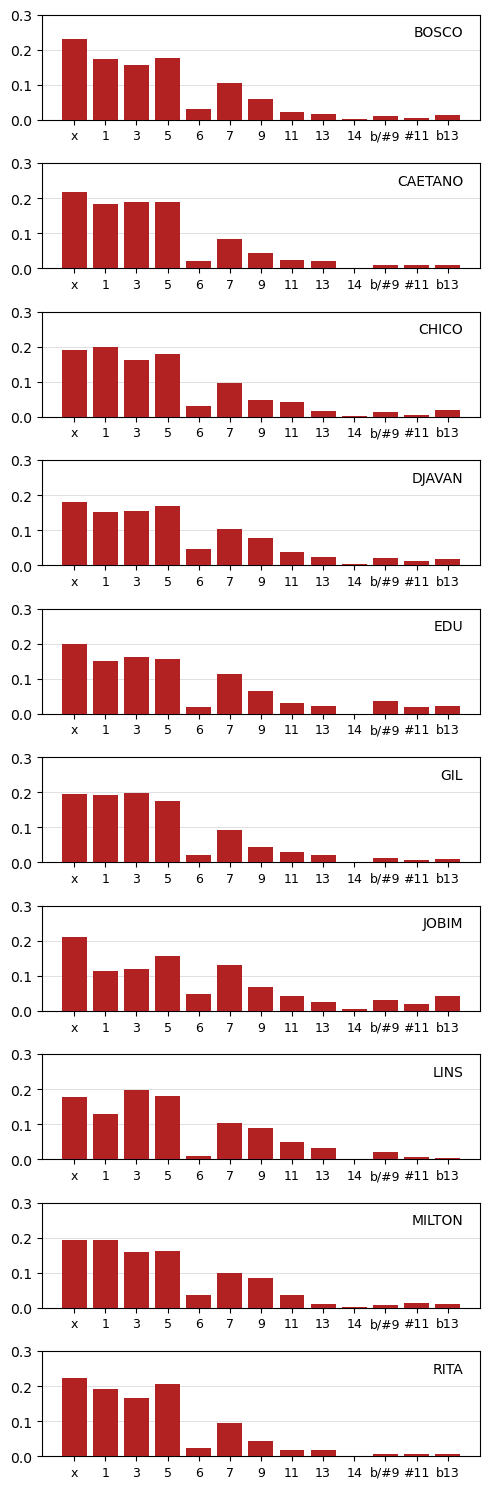

In [25]:
note_functions = ['x', '1', '3', '5', '6', '7', '9', '11', '13', '14', 'b9/#9', '#11', 'b13']

plt.figure(figsize = (5, 15))

sub = 1
for corpus in note_function['corpus_id'].unique():
    count_note_function = Counter(note_function[note_function['corpus_id'] == corpus]['note_function'])
    count_note_function_ordered = {nf: count_note_function[nf] for nf in note_functions}
    total_note_function = sum(count_note_function.values())
    prop_note_function_ordered = np.array(list(count_note_function_ordered.values()))/total_note_function

    plt.subplot(10, 1, sub)
    plt.grid(True, color = "lightgrey", linewidth = "0.5",  alpha = 1, axis = "y", zorder = 0) 
    plt.bar(x = ['x', '1', '3', '5', '6', '7', '9', '11', '13', '14', 'b/#9', '#11', 'b13'], height = prop_note_function_ordered, color = 'firebrick', zorder = 3)
    plt.xticks(fontsize = 9)
    plt.ylim(0, 0.3)
    plt.yticks([0, 0.1, 0.2, 0.3])
    plt.text(x = 12.5, y = 0.27, s = corpus, ha = 'right', va = 'top')
    sub += 1

plt.tight_layout()

# plt.savefig('note-function-dist.pdf', format  = 'pdf', dpi = 300, bbox_inches = 'tight')

### Average melodic anchoring index

In [26]:
cmi_by_piece = {}
for corpus in note_function['corpus_id'].unique():
    cmi_by_piece[corpus] = []
    for composition in note_function[(note_function['corpus_id'] == corpus)]['composition_id'].unique():
        df_aux = note_function[(note_function['corpus_id'] == corpus) & (note_function['composition_id'] == composition)]
        cmi_by_piece[corpus].append(compute_anchoring_index(df_aux))

cmi_average = {}
for corpus in note_function['corpus_id'].unique():
    cmi_average[corpus] = np.mean(cmi_by_piece[corpus]).round(3)

pd.DataFrame.from_dict(cmi_average, orient = 'index', columns = ['MAI'])

,MAI
BOSCO,0.704
CAETANO,0.721
CHICO,0.704
DJAVAN,0.643
EDU,0.623
GIL,0.714
JOBIM,0.582
LINS,0.649
MILTON,0.684
RITA,0.741


### NF web of two pieces: Saúde, by Rita Lee (top), and Angela, by Tom Jobim (below)

<Figure size 2500x2500 with 0 Axes>

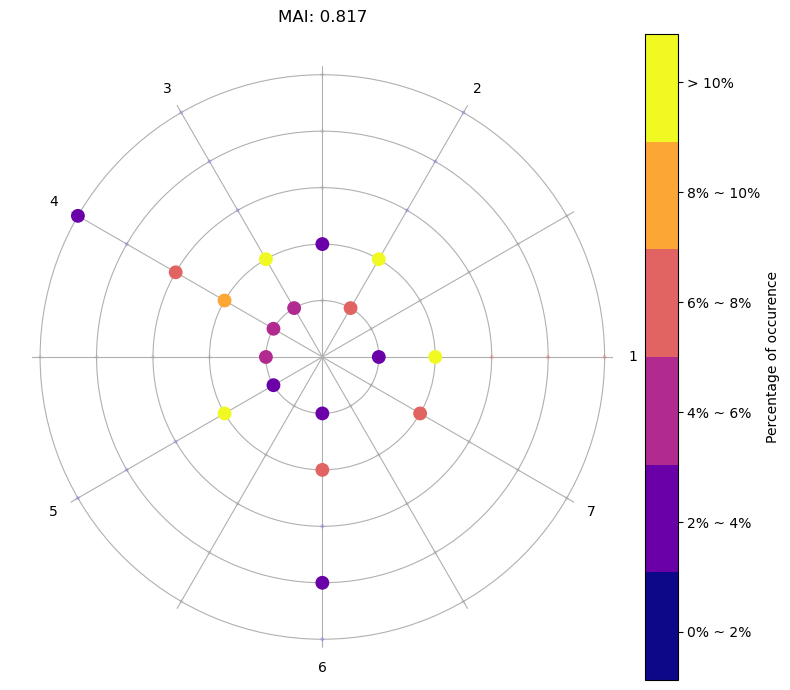

In [27]:
df_aux = note_function[(note_function['corpus_id'] == 'RITA') & (note_function['composition_name'] == 'Saude')]

plot_nf_web(df_aux)

<Figure size 2500x2500 with 0 Axes>

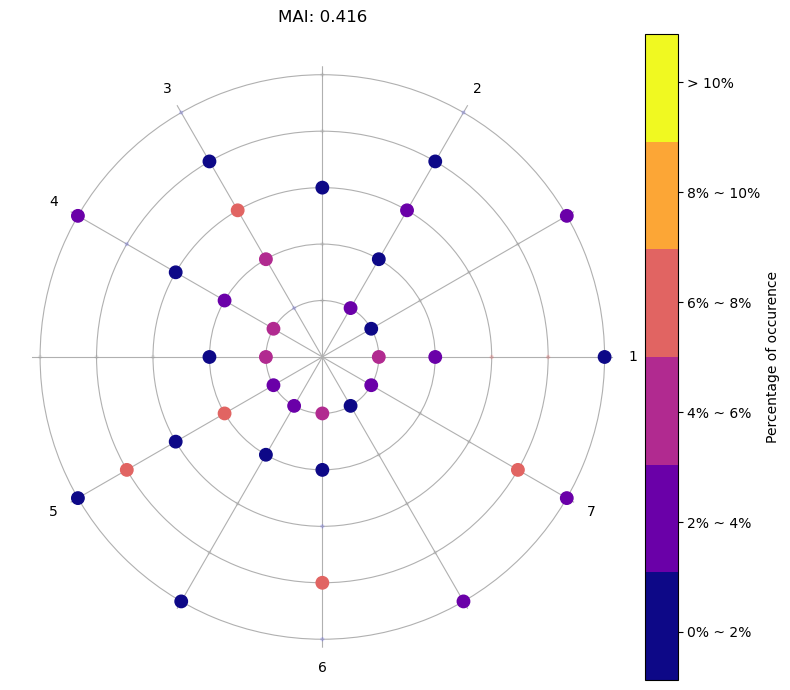

In [28]:
df_aux = note_function[(note_function['corpus_id'] == 'JOBIM') & (note_function['composition_name'] == 'Angela')]

plot_nf_web(df_aux)

# Examples

## Parsons Code

Example of converting c-words to Parsons code. Note that this conversion entails a loss of information, as multiple c-letters are mapped to a single symbol.

In [14]:
contour_rhythm_2 = contour_to_parsons(contour_rhythm)

contour_rhythm_2

,corpus_id,composition_id,composition_name,word_index,c_word,r_word,c_word_parsons
0,BOSCO,1,Agnus sei,1,uuPu,jjb,RRUR
1,BOSCO,1,Agnus sei,2,pppA,fsb,DDDU
2,BOSCO,1,Agnus sei,3,uuPu,jjb,RRUR
3,BOSCO,1,Agnus sei,4,upPPAupu,jjbjeb,RDUUURDR
4,BOSCO,1,Agnus sei,5,PupuP,jjj,URDRU
...,...,...,...,...,...,...,...
8421,RITA,50,O futuro me absolve,11,PpPpPp,ejjj,UDUDUD
8422,RITA,50,O futuro me absolve,12,pPppS,rje,DUDDU
8423,RITA,50,O futuro me absolve,13,uuuppPp,ejjjb,RRRDDUD
8424,RITA,50,O futuro me absolve,14,Pp,ej,UD


## Dowling notation

Example of converting c-words to the notation used by Dowling.

In [15]:
contour_rhythm_3 = contour_to_dowling(contour_rhythm)

contour_rhythm_3

,corpus_id,composition_id,composition_name,word_index,c_word,r_word,c_word_parsons,c_word_dowling
0,BOSCO,1,Agnus sei,1,uuPu,jjb,RRUR,uuTu
1,BOSCO,1,Agnus sei,2,pppA,fsb,DDDU,tttS
2,BOSCO,1,Agnus sei,3,uuPu,jjb,RRUR,uuTu
3,BOSCO,1,Agnus sei,4,upPPAupu,jjbjeb,RDUUURDR,utTTSutu
4,BOSCO,1,Agnus sei,5,PupuP,jjj,URDRU,TutuT
...,...,...,...,...,...,...,...,...
8421,RITA,50,O futuro me absolve,11,PpPpPp,ejjj,UDUDUD,TtTtTt
8422,RITA,50,O futuro me absolve,12,pPppS,rje,DUDDU,tTttL
8423,RITA,50,O futuro me absolve,13,uuuppPp,ejjjb,RRRDDUD,uuuttTt
8424,RITA,50,O futuro me absolve,14,Pp,ej,UD,Tt


## Visualization of r-words

Example of visualization of r-words. This code block requires the installation of Abjad Python package and LilyPond.

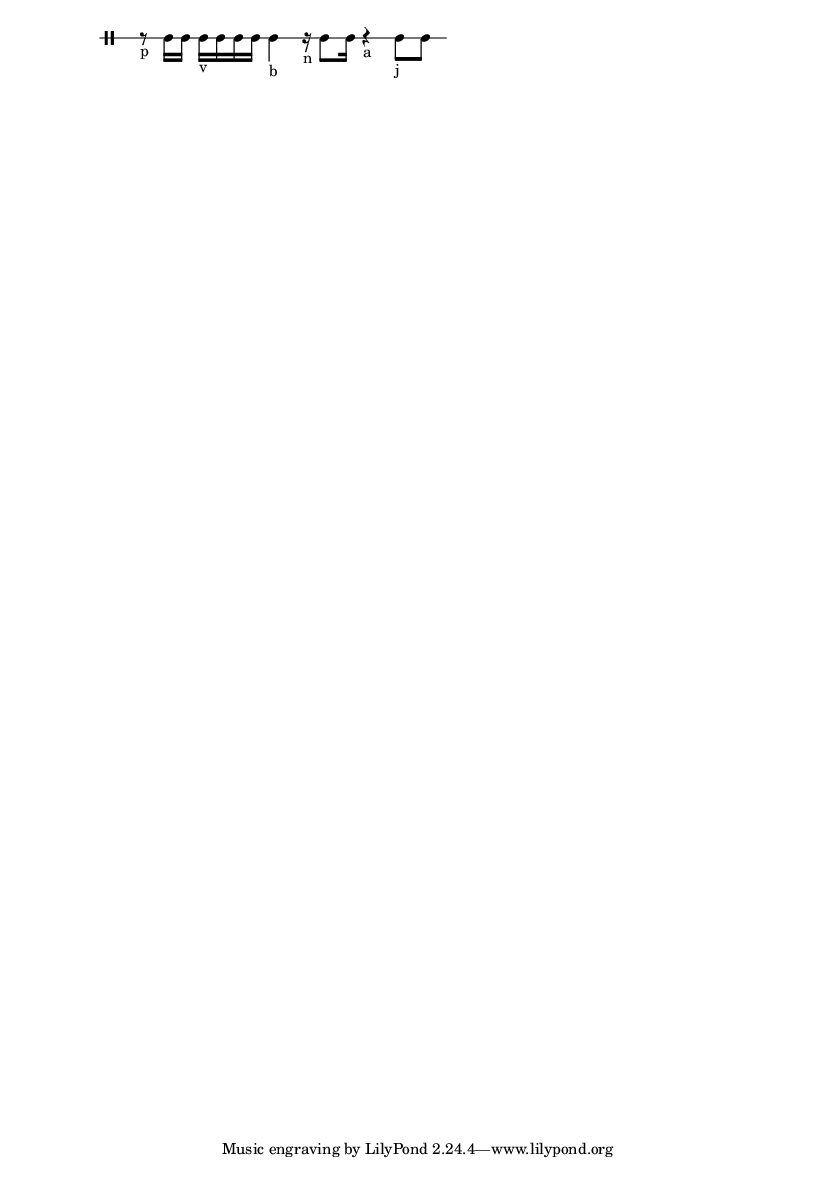

In [36]:
visualize_r_word('pvbnaj')

## Convert r-words to attack points

Example of converting r-words into length-12 vectors representing onset positions for each r-letter.

In [37]:
r_word_to_attack_points('pvbnaj')

[array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
 array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]),
 array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])]

## Convert chord type to pitch-class

Example of converting chord types into pitch-class vectors, similar to the General Chord Types, by Cambouropoulos.

In [23]:
harmony_2 = chord_type_to_pitch_class(harmony)

harmony_2

,corpus_id,composition_id,composition_name,chord_index,root,bass,chord_type,chord_symbol,functional_category,key,mode,position,ct_pitch_class
0,BOSCO,1,Agnus sei,1,4,4,z2,*m7.9,I,4,minor,1.0,"[0, 2, 3, 7, 10]"
1,BOSCO,1,Agnus sei,2,2,9,z2,*m7.9,bVIIm7,4,minor,8.0,"[0, 2, 3, 7, 10]"
2,BOSCO,1,Agnus sei,3,1,1,y0,*Ø,VI,4,minor,10.0,"[0, 3, 6, 10]"
3,BOSCO,1,Agnus sei,4,0,0,Z0,*M7,VI,4,minor,11.0,"[0, 4, 7, 11]"
4,BOSCO,1,Agnus sei,5,2,6,z1,*m6,II__X,4,minor,12.0,"[0, 3, 7, 9]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17048,RITA,50,O futuro me absolve,22,2,2,V0,*,IV,9,major,20.5,"[0, 4, 7]"
17049,RITA,50,O futuro me absolve,23,9,9,V0,*,I,9,major,21.0,"[0, 4, 7]"
17050,RITA,50,O futuro me absolve,24,2,2,V0,*,IV,9,major,21.5,"[0, 4, 7]"
17051,RITA,50,O futuro me absolve,25,9,9,V0,*,I,9,major,22.0,"[0, 4, 7]"
